

In a univariate problem, comparing two groups is relatively straightforward. We can compare means, standard deviations, or visualize the distributions directly.

In a multivariate problem, the situation is different. A case and a control may differ only slightly in each individual predictor, but the **joint pattern across several correlated predictors** may still be informative.

Mahalanobis distance is useful in this setting because it measures distance while accounting for:

- the variance of each predictor,
- the covariance between predictors,
- and the overall multivariate structure of the data.

This tutorial develops the idea step by step using a synthetic case-control dataset with correlated predictors. It also shows what PCA whitening, PCA dimensionality reduction, Ledoit-Wolf covariance regularization, and autoencoder-based denoising actually do.

A few important points are worth stating at the beginning:

1. **Class imbalance by itself does not create a bimodal Mahalanobis-distance distribution.** Bimodality can appear when cases and controls have different multivariate distributions.
2. **Mahalanobis distance already accounts for linear correlation through the covariance matrix.**
3. **PCA whitening with all components retained is a re-expression of the same geometry.** It decorrelates the variables, but it does not automatically improve separation or denoise the data.
4. **Denoising requires removing or shrinking some component of the data.** Examples include PCA truncation, covariance regularization, or a denoising autoencoder trained to reconstruct clean signal from noisy input.


##  Mathematical definition

For an observation $\mathbf{x}$, mean vector $\boldsymbol{\mu}$, and covariance matrix $\boldsymbol{\Sigma}$, the Mahalanobis distance is

$$
D_M(\mathbf{x}) =
\sqrt{
(\mathbf{x} - \boldsymbol{\mu})^T
\boldsymbol{\Sigma}^{-1}
(\mathbf{x} - \boldsymbol{\mu})
}.
$$

Compare this with Euclidean distance:

$$
D_E(\mathbf{x}) =
\sqrt{
\sum_j (x_j - \mu_j)^2
}.
$$

Euclidean distance treats all directions equally.

Mahalanobis distance does not. A deviation along a direction with large natural variance is treated as less unusual than the same numerical deviation along a direction with small variance. Correlation is also incorporated through the inverse covariance matrix.

Conceptually, Mahalanobis distance asks:

> *How unusual is this multivariate profile relative to the covariance structure of the reference population?*


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPRegressor

np.random.seed(42)

##  Create a synthetic correlated case-control dataset

We will create five correlated predictors.

The control group will have a mean close to zero. The case group will have a modest shift across several predictors.

The predictors are deliberately correlated so that a simple Euclidean interpretation is not ideal.

In [2]:
n_controls = 600
n_cases = 200
n_features = 5

cov = np.array([
    [1.00, 0.80, 0.60, 0.40, 0.30],
    [0.80, 1.00, 0.70, 0.50, 0.40],
    [0.60, 0.70, 1.00, 0.60, 0.50],
    [0.40, 0.50, 0.60, 1.00, 0.60],
    [0.30, 0.40, 0.50, 0.60, 1.00]
])

control_mean = np.zeros(n_features)
case_mean = np.array([0.8, 0.6, 0.5, 0.4, 0.3])

controls = np.random.multivariate_normal(
    mean=control_mean,
    cov=cov,
    size=n_controls
)

cases = np.random.multivariate_normal(
    mean=case_mean,
    cov=cov,
    size=n_cases
)

X = np.vstack([controls, cases])
y = np.array([0] * n_controls + [1] * n_cases)

df = pd.DataFrame(
    X,
    columns=[f"Feature_{i+1}" for i in range(n_features)]
)

df["Group"] = np.where(y == 0, "Control", "Case")

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Group
0,-0.802644,-0.670422,0.406093,-0.491523,-0.493302,Control
1,0.817060,0.918237,0.131868,-0.062497,-1.128952,Control
2,0.925333,-0.267855,-0.297533,1.192945,0.462326,Control
3,0.438576,-0.323829,0.219740,1.247100,0.844891,Control
4,-0.855830,-1.476189,-1.866599,-0.605574,-0.916277,Control


##  Inspect the correlation structure

Before calculating any multivariate distance, it is useful to inspect the correlation matrix.

If predictors are strongly correlated, several variables may partly carry the same information.

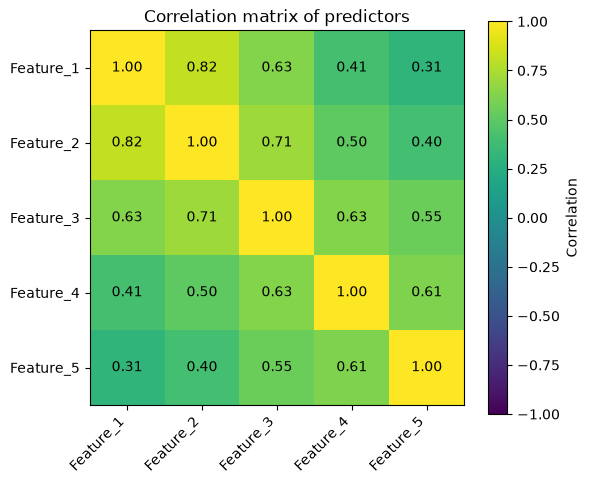

In [3]:
corr = df.drop(columns="Group").corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(n_features):
    for j in range(n_features):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center")

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation matrix of predictors")
plt.tight_layout()
plt.show()

##  Why not simply use Euclidean distance?

Suppose Feature 1 and Feature 2 are strongly correlated.

A subject who is high on both variables may not be particularly unusual because those variables usually move together.

Euclidean distance ignores this. Mahalanobis distance uses the covariance matrix to recognize that such joint movement is expected.

This is why Mahalanobis distance is sometimes described as a **covariance-adjusted multivariate distance**.

##  Standardize the predictors

Mahalanobis distance already incorporates scale through the covariance matrix, so standardization is not mathematically required in every case.

However, standardization is often convenient in applied workflows, especially when predictors have very different units.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##  A stable Mahalanobis distance function

Directly inverting the empirical covariance matrix can be unstable when predictors are highly correlated, or when the number of predictors is large relative to the sample size.

Instead of using a raw inverse covariance matrix, we will often use **Ledoit-Wolf shrinkage covariance**.

Ledoit-Wolf estimates a covariance matrix that is pulled slightly toward a better-conditioned structure. This usually makes the precision matrix \(\Sigma^{-1}\) more stable.

In [5]:
def mahalanobis_from_precision(X, mean, precision):
    diff = X - mean
    d2 = np.einsum("ij,jk,ik->i", diff, precision, diff)
    d2 = np.maximum(d2, 0)
    return np.sqrt(d2)

##  Pooled Mahalanobis distance

We first estimate one mean and covariance matrix from the entire sample.

This gives the distance of each subject from the **overall multivariate center**.

This can be useful descriptively, but in a case-control problem it is not always the most interpretable reference because the overall center contains both cases and controls.

In [6]:
lw_global = LedoitWolf().fit(X_scaled)

global_mean = X_scaled.mean(axis=0)
global_precision = lw_global.precision_

md_global = mahalanobis_from_precision(
    X_scaled,
    global_mean,
    global_precision
)

df["MD_global"] = md_global

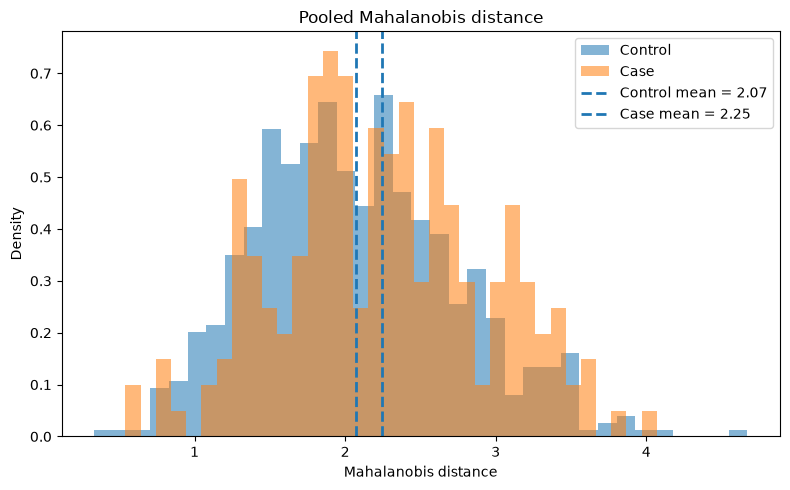

Control mean MD: 2.073
Case mean MD:    2.246
Difference:      0.173


In [7]:
control_md = df.loc[df["Group"] == "Control", "MD_global"]
case_md = df.loc[df["Group"] == "Case", "MD_global"]

mean_control = control_md.mean()
mean_case = case_md.mean()

plt.figure(figsize=(8, 5))

plt.hist(control_md, bins=35, density=True, alpha=0.55, label="Control")
plt.hist(case_md, bins=35, density=True, alpha=0.55, label="Case")

plt.axvline(
    mean_control,
    linestyle="--",
    linewidth=2,
    label=f"Control mean = {mean_control:.2f}"
)

plt.axvline(
    mean_case,
    linestyle="--",
    linewidth=2,
    label=f"Case mean = {mean_case:.2f}"
)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Pooled Mahalanobis distance")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Control mean MD: {mean_control:.3f}")
print(f"Case mean MD:    {mean_case:.3f}")
print(f"Difference:      {mean_case - mean_control:.3f}")

## Interpreting the distribution

If the case and control distributions overlap strongly, Mahalanobis distance alone does not separate the groups well.

If cases tend to occupy a different region of multivariate space, their distances may shift to the right.

A visibly bimodal distribution is possible, but **imbalance itself is not the cause**. The important issue is whether the two groups have different means, covariance structures, or latent subgroups.

##  A more useful case-control formulation: distance from the control distribution

For many biomedical problems, a more interpretable question is:

> How far is each subject from the multivariate profile of the controls?

We can therefore estimate the mean and covariance matrix **using controls only**, and then calculate the Mahalanobis distance of both controls and cases relative to that reference.

This changes the interpretation.

A high value now means that the subject has an unusual multivariate profile relative to the control population.

In [8]:
X_control = X_scaled[y == 0]

lw_control = LedoitWolf().fit(X_control)

control_mean_ref = X_control.mean(axis=0)
control_precision_ref = lw_control.precision_

md_to_control = mahalanobis_from_precision(
    X_scaled,
    control_mean_ref,
    control_precision_ref
)

df["MD_to_control"] = md_to_control

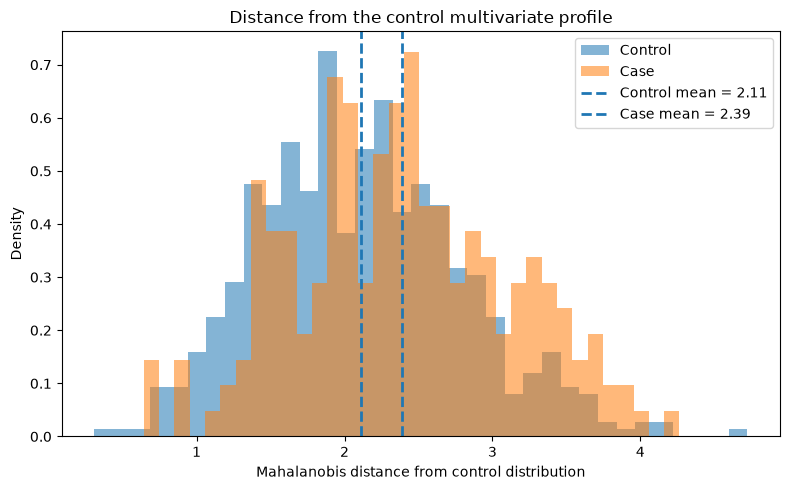

Control mean MD: 2.109
Case mean MD:    2.386
Difference:      0.277


In [9]:
control_md = df.loc[df["Group"] == "Control", "MD_to_control"]
case_md = df.loc[df["Group"] == "Case", "MD_to_control"]

mean_control = control_md.mean()
mean_case = case_md.mean()

plt.figure(figsize=(8, 5))

plt.hist(control_md, bins=35, density=True, alpha=0.55, label="Control")
plt.hist(case_md, bins=35, density=True, alpha=0.55, label="Case")

plt.axvline(
    mean_control,
    linestyle="--",
    linewidth=2,
    label=f"Control mean = {mean_control:.2f}"
)

plt.axvline(
    mean_case,
    linestyle="--",
    linewidth=2,
    label=f"Case mean = {mean_case:.2f}"
)

plt.xlabel("Mahalanobis distance from control distribution")
plt.ylabel("Density")
plt.title("Distance from the control multivariate profile")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Control mean MD: {mean_control:.3f}")
print(f"Case mean MD:    {mean_case:.3f}")
print(f"Difference:      {mean_case - mean_control:.3f}")

## Quantifying separation with AUC

A Mahalanobis distance can be treated as a **continuous score**: subjects farther from the control distribution receive larger values.

We can summarize how well that score ranks cases above controls using the ROC AUC.

$$
AUC = P(\text{score of a random case} > \text{score of a random control})
$$

Important: this does **not** automatically turn Mahalanobis distance into a validated predictive model.

If the same dataset is used to estimate the covariance structure and evaluate AUC, the result is mainly descriptive. For prediction, the preprocessing and covariance estimation should be fitted inside a training set and evaluated on held-out data.

In [10]:
auc_control_reference = roc_auc_score(y, md_to_control)

print(
    "AUC using distance from control distribution:",
    round(auc_control_reference, 3)
)

AUC using distance from control distribution: 0.612


##  PCA: decorrelation versus denoising

PCA is often described as a way to remove correlation.

That statement is correct, but we need to distinguish two different uses of PCA.

### PCA with all components retained

If all principal components are retained, PCA is simply an invertible linear transformation.

The components are uncorrelated, but no information has been removed.

If whitening is also applied, the components are additionally scaled to unit variance.

For an invertible transformation, Mahalanobis geometry is unchanged. Therefore, full PCA whitening should give essentially the same Mahalanobis distances as the original space, apart from numerical differences.

This is an important point: **decorrelation is not the same thing as denoising**.

In [11]:
pca_white = PCA(n_components=n_features, whiten=True)
X_white = pca_white.fit_transform(X_scaled)

white_cov = np.cov(X_white, rowvar=False)

print("Covariance matrix after whitening:")
print(np.round(white_cov, 3))

Covariance matrix after whitening:
[[ 1.  0.  0. -0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  0.  1. -0. -0.]
 [-0.  0. -0.  1. -0.]
 [ 0.  0. -0. -0.  1.]]


In [12]:
# Mahalanobis distance in whitened space
white_mean = X_white.mean(axis=0)

# covariance is approximately identity, but we estimate it explicitly here
lw_white = LedoitWolf().fit(X_white)

md_white = mahalanobis_from_precision(
    X_white,
    white_mean,
    lw_white.precision_
)

print(
    "Correlation between global MD and whitened-space MD:",
    round(np.corrcoef(md_global, md_white)[0, 1], 6)
)

Correlation between global MD and whitened-space MD: 0.999931


The correlation should be extremely high.

If all components are retained, whitening is useful for interpretation or numerical convenience, but it should not be presented as a method that creates new case-control separation.

##  PCA dimensionality reduction as denoising

PCA can become a denoising method when we **discard some components**.

The idea is that high-variance components may capture stable structure, while some low-variance components may contain measurement noise.

This assumption is not guaranteed to be correct. A biologically important signal can also live in a low-variance component.

Therefore, PCA truncation should be treated as a modeling choice and ideally validated out of sample.

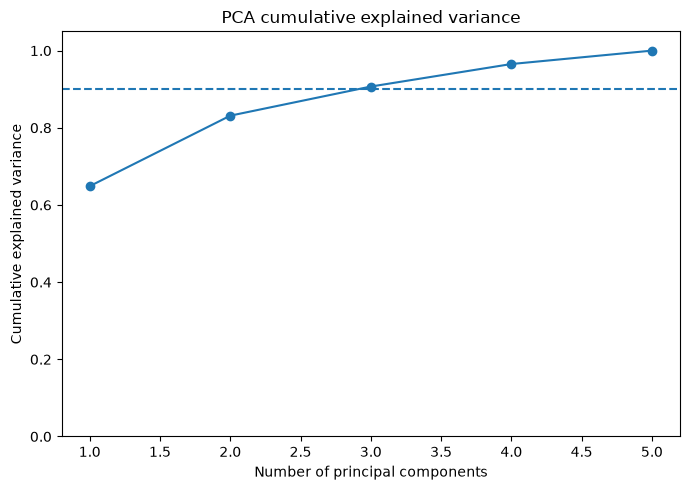

Explained variance ratio:
[0.649 0.183 0.075 0.058 0.035]


In [13]:
pca_full = PCA().fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(
    np.arange(1, n_features + 1),
    cum_var,
    marker="o"
)
plt.axhline(0.90, linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Explained variance ratio:")
print(np.round(pca_full.explained_variance_ratio_, 3))

In [14]:
# Keep enough PCs to explain at least 90% of the variance
n_keep = np.argmax(cum_var >= 0.90) + 1

pca_reduced = PCA(n_components=n_keep)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print("Number of retained PCs:", n_keep)

Number of retained PCs: 3


To preserve the same case-control interpretation, we again estimate the reference distribution using the controls only, but now in the reduced PCA space.

In [15]:
X_pca_control = X_pca_reduced[y == 0]

lw_pca = LedoitWolf().fit(X_pca_control)

pca_control_mean = X_pca_control.mean(axis=0)

md_pca_reduced = mahalanobis_from_precision(
    X_pca_reduced,
    pca_control_mean,
    lw_pca.precision_
)

auc_pca_reduced = roc_auc_score(y, md_pca_reduced)

print("AUC after PCA dimensionality reduction:", round(auc_pca_reduced, 3))

AUC after PCA dimensionality reduction: 0.603


##  Ledoit-Wolf regularization

Mahalanobis distance requires the inverse covariance matrix.

This can be problematic when:

- predictors are strongly correlated,
- the number of predictors is large,
- the sample size is limited,
- or the covariance matrix is close to singular.

Ledoit-Wolf shrinkage is useful because it stabilizes the covariance estimate.

It is important to understand what it does: **Ledoit-Wolf is primarily a covariance-estimation method, not a general-purpose denoising transformation of individual observations.**

It makes Mahalanobis distance more numerically reliable.

In [16]:
# Compare condition number of ordinary covariance and Ledoit-Wolf covariance

sample_cov = np.cov(X_control, rowvar=False)
lw_cov = lw_control.covariance_

cond_sample = np.linalg.cond(sample_cov)
cond_lw = np.linalg.cond(lw_cov)

print(f"Condition number, sample covariance: {cond_sample:.2f}")
print(f"Condition number, Ledoit-Wolf:       {cond_lw:.2f}")

Condition number, sample covariance: 17.43
Condition number, Ledoit-Wolf:       16.51


A smaller condition number generally indicates a matrix that is easier and safer to invert numerically.

## What is a real denoising autoencoder?

An ordinary autoencoder trained with

$$
X \rightarrow X
$$

is a reconstruction model. A bottleneck may force compression, but reconstruction alone does not guarantee denoising.

A **denoising autoencoder** is trained differently:

$$
X_{\text{noisy}} \rightarrow X_{\text{clean}}
$$

The model is deliberately given corrupted input and asked to recover the cleaner version.

This encourages the network to learn stable structure rather than reproduce every perturbation.


For a synthetic example, we know the clean data because we generated it ourselves. We can therefore add noise deliberately and train a denoising model.

In [17]:
# Standardized data will serve as the clean target
X_clean = X_scaled.copy()

# Add Gaussian noise
noise_sd = 0.50
X_noisy = X_clean + np.random.normal(
    loc=0,
    scale=noise_sd,
    size=X_clean.shape
)

# Train a small denoising autoencoder-like network
dae = MLPRegressor(
    hidden_layer_sizes=(8, 3, 8),
    activation="relu",
    max_iter=3000,
    random_state=42
)

dae.fit(X_noisy, X_clean)

X_denoised = dae.predict(X_noisy)

Because we know the clean synthetic data, we can directly compare reconstruction error before and after denoising.

In [18]:
mse_noisy = np.mean((X_noisy - X_clean) ** 2)
mse_denoised = np.mean((X_denoised - X_clean) ** 2)

print(f"MSE of noisy data:    {mse_noisy:.4f}")
print(f"MSE after denoising:  {mse_denoised:.4f}")

MSE of noisy data:    0.2586
MSE after denoising:  0.2589


Now we can compute control-referenced Mahalanobis distance in the denoised representation.

In [19]:
X_denoised_control = X_denoised[y == 0]

lw_dae = LedoitWolf().fit(X_denoised_control)
dae_control_mean = X_denoised_control.mean(axis=0)

md_dae = mahalanobis_from_precision(
    X_denoised,
    dae_control_mean,
    lw_dae.precision_
)

auc_dae = roc_auc_score(y, md_dae)

print("AUC after denoising autoencoder:", round(auc_dae, 3))

AUC after denoising autoencoder: 0.594


##  Compare the methods

We will compare three scores:

1. **Ledoit-Wolf control-reference Mahalanobis distance**
2. **PCA-reduced control-reference Mahalanobis distance**
3. **Denoising-autoencoder control-reference Mahalanobis distance**

I leave full PCA whitening out of this comparison because retaining all components does not remove information and should not be interpreted as denoising.

In [20]:
results = pd.DataFrame({
    "Method": [
        "Ledoit-Wolf",
        "PCA reduction",
        "Denoising autoencoder"
    ],
    "AUC": [
        auc_control_reference,
        auc_pca_reduced,
        auc_dae
    ]
})

results

,Method,AUC
0,Ledoit-Wolf,0.611767
1,PCA reduction,0.602892
2,Denoising autoencoder,0.594025


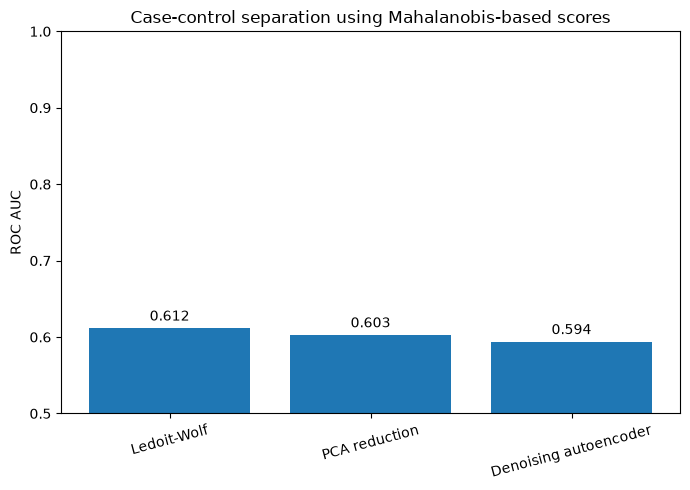

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    results["Method"],
    results["AUC"]
)

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("ROC AUC")
ax.set_title("Case-control separation using Mahalanobis-based scores")
ax.tick_params(axis="x", rotation=15)

# Write values on the bars
ax.bar_label(
    bars,
    labels=[f"{x:.3f}" for x in results["AUC"]],
    padding=3
)

plt.tight_layout()
plt.show()

##  Plot the mean separation for each method

AUC summarizes ranking performance, but the distributions are still important.

Below, the dashed vertical lines indicate the mean Mahalanobis distance for controls and cases.

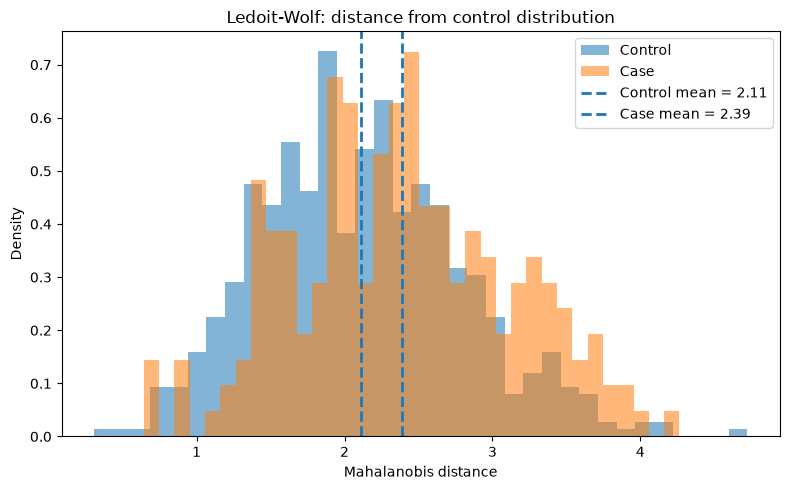

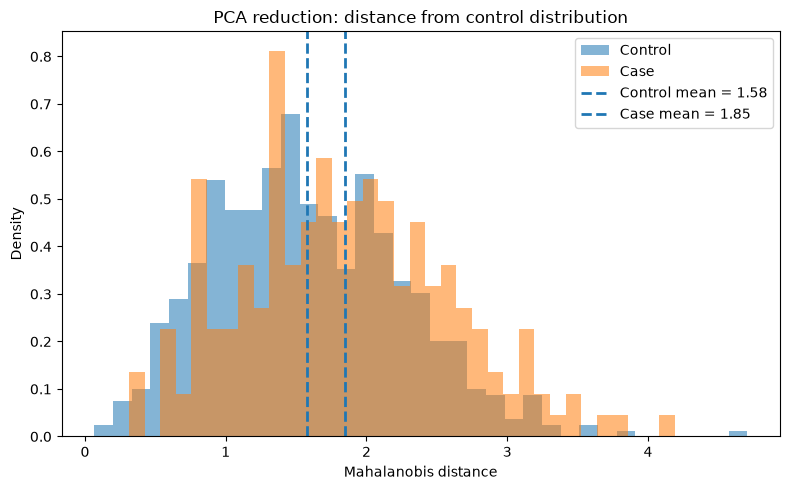

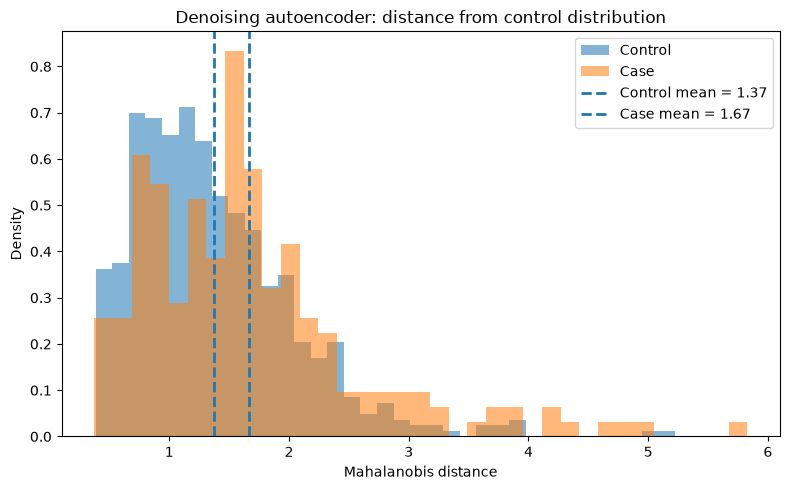

In [22]:
def plot_group_md(md_values, title):
    control_vals = md_values[y == 0]
    case_vals = md_values[y == 1]

    control_mean = control_vals.mean()
    case_mean = case_vals.mean()

    plt.figure(figsize=(8, 5))

    plt.hist(
        control_vals,
        bins=35,
        density=True,
        alpha=0.55,
        label="Control"
    )

    plt.hist(
        case_vals,
        bins=35,
        density=True,
        alpha=0.55,
        label="Case"
    )

    plt.axvline(
        control_mean,
        linestyle="--",
        linewidth=2,
        label=f"Control mean = {control_mean:.2f}"
    )

    plt.axvline(
        case_mean,
        linestyle="--",
        linewidth=2,
        label=f"Case mean = {case_mean:.2f}"
    )

    plt.xlabel("Mahalanobis distance")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_group_md(
    md_to_control,
    "Ledoit-Wolf: distance from control distribution"
)

plot_group_md(
    md_pca_reduced,
    "PCA reduction: distance from control distribution"
)

plot_group_md(
    md_dae,
    "Denoising autoencoder: distance from control distribution"
)

##  What does a larger mean distance in cases actually mean?

Suppose the control mean Mahalanobis distance is 2.0 and the case mean is 2.6.

This does **not** mean that cases are "2.6 units diseased."

It means that, on average, the multivariate predictor profiles of cases lie farther from the reference control distribution after accounting for covariance.

The interpretation depends completely on the variables included in the analysis.

For example, if the predictors are biomarkers, the distance summarizes how unusual a subject's biomarker profile is relative to controls.

If the predictors are polygenic scores, the distance summarizes deviation in a multivariate genetic-score profile.

If the predictors are imaging measurements, it summarizes deviation in the joint imaging pattern.

##  Does class imbalance cause bimodality?

No.

Suppose there are 10,000 controls and 1,000 cases.

If cases and controls are generated from the same multivariate distribution, the Mahalanobis distance distribution should not become bimodal merely because one group is larger.

Imbalance changes the **relative height or density contribution** of the groups and can influence a pooled mean/covariance estimate. But a second mode requires some form of distributional difference or latent mixture structure.

Possible causes of multimodality include:

- different case and control means,
- different covariance structures,
- population stratification,
- batch effects,
- hidden subtypes,
- measurement artifacts,
- or genuinely distinct biological subgroups.

##  Why a control-reference covariance is often preferable

When the scientific question is whether cases depart from a healthy or baseline distribution, estimating the reference mean and covariance from controls has a natural interpretation.

However, this approach also has assumptions.

The control covariance estimate should be sufficiently stable. If there are many predictors relative to controls, regularization becomes important.

Also, if controls themselves contain strong substructure, one covariance matrix may be too simple.

## High-dimensional data: when $p$ approaches or exceeds $n$

If the number of predictors $p$ is similar to or larger than the number of subjects $n$, the ordinary covariance matrix may be singular.

Then $\Sigma^{-1}$ cannot be estimated reliably using the naive sample covariance.

Possible strategies include:

- Ledoit-Wolf or another shrinkage covariance estimator,
- PCA followed by Mahalanobis distance in a lower-dimensional space,
- sparse precision-matrix estimation,
- robust covariance estimation,
- or domain-specific feature selection.

For omics data, this issue is especially important because the number of features can be extremely large.


## Outlier detection using the chi-square connection

Under an ideal multivariate normal model with $p$ variables,

$$
D_M^2 \sim \chi^2_p
$$

approximately.

This gives a theoretical way to flag unusually large distances.

For example:

In [23]:
from scipy.stats import chi2

alpha = 0.99
threshold_squared = chi2.ppf(alpha, df=n_features)
threshold = np.sqrt(threshold_squared)

print(
    f"Approximate {alpha:.0%} Mahalanobis-distance threshold:",
    round(threshold, 3)
)

Approximate 99% Mahalanobis-distance threshold: 3.884


In real biomedical data, however, multivariate normality may be imperfect. I would therefore use this threshold cautiously and inspect empirical distributions as well.

##  A simple train-test version for predictive evaluation

If the goal is prediction rather than exploratory analysis, preprocessing must be estimated on the training data only.

Otherwise information from the test set leaks into the score.

Below is a minimal example.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Fit scaling on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Estimate control reference from TRAINING controls only
X_train_controls = X_train_scaled[y_train == 0]

lw_train = LedoitWolf().fit(X_train_controls)
train_control_mean = X_train_controls.mean(axis=0)

# Score held-out test subjects
md_test = mahalanobis_from_precision(
    X_test_scaled,
    train_control_mean,
    lw_train.precision_
)

test_auc = roc_auc_score(y_test, md_test)

print("Held-out test AUC:", round(test_auc, 3))

Held-out test AUC: 0.584


##  When should I use each method?

### Mahalanobis distance with ordinary covariance

Use it when the dataset is low-dimensional, reasonably large, and the covariance matrix is well-conditioned.

### Ledoit-Wolf Mahalanobis distance

A strong default when predictors are correlated and covariance inversion may be unstable.

### PCA whitening

Useful for producing uncorrelated, unit-variance coordinates.

If all components are retained, it changes the coordinate system but does not inherently denoise the data.

### PCA dimensionality reduction

Useful when many predictors contain redundant structure and you have a defensible reason to discard lower-variance components.

Validate the number of retained components.

### Denoising autoencoder

Potentially useful when the signal is nonlinear and enough data are available.

It should be evaluated carefully with held-out data. A neural network that reconstructs its own input is not automatically a denoising model.

##  Practical workflow for a real case-control dataset

For a real project, I would use the following sequence:

1. Check missingness, scaling, extreme values, and data quality.
2. Inspect predictor correlations.
3. Visualize cases and controls using a lower-dimensional method such as PCA.
4. Decide what the reference distribution should be.
5. If the goal is deviation from controls, estimate the mean and covariance from controls.
6. Use covariance shrinkage when predictors are strongly correlated or covariance inversion is unstable.
7. Calculate Mahalanobis distance.
8. Plot the case and control distributions separately.
9. Add group mean lines.
10. Quantify separation using effect sizes or AUC if appropriate.
11. If trying PCA reduction or autoencoder denoising, compare them in held-out data.
12. Investigate extreme-distance subjects for batch effects, ancestry structure, hidden subgroups, or biologically interesting profiles.

##  Final interpretation

Mahalanobis distance is useful because it converts a multivariate profile into a single quantity while preserving information about covariance.

Its main strength is not that it "removes correlation." Rather, it **uses correlation correctly when defining distance**.

For case-control data, the most useful version is often the distance of each subject from a control reference distribution.

Regularized covariance can make this calculation stable. PCA can help simplify the feature space, but full whitening is not itself denoising. PCA truncation removes dimensions and therefore may denoise. A denoising autoencoder can model nonlinear structure, but it requires a more careful training and validation strategy.

The important question is therefore not simply:

> Which denoising method gives the highest AUC?

A better question is:

> Which representation captures reproducible structure in the data without removing biologically meaningful information?

That distinction becomes especially important in high-dimensional biomedical datasets.

##  Reproducibility

The examples in this tutorial use synthetic data and a fixed random seed.

Package versions can be checked with:

In [25]:
import sklearn
import scipy
import matplotlib

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 2.5.1
Pandas: 3.0.5
scikit-learn: 1.9.0
SciPy: 1.18.0
Matplotlib: 3.11.1
